# TP1 - Estimators and Stochastic Gradient Descent  
**Computational Statistics (MVA 2025-2026)**  
**École Normale Supérieure Paris-Saclay**

**Student:** Yannaël Bossard  
**Email:** yannael.bossard@ens-paris-saclay.fr  
**Date:** 12 October 2025  
**Deadline:** 24 / 10 / 2025 - 23 h 59  


### Objective:
This practical session introduces the concept of **estimators** and the use of the **stochastic gradient descent (SGD)** algorithm for empirical risk minimization.  

In [173]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [174]:
import sys, os
from google.colab import drive
drive.mount('/content/drive')

!ls -al "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TP1"
current_path = "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TP1"
sys.path.append(current_path)
img_path1 = current_path + "/1.jpg"
img_path2 = current_path + "/2.jpg"
img_path3 = current_path + "/3.jpg"
img_path4 = current_path + "/4.jpg"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
total 2639
-rw------- 1 root root  151446 Oct 12 10:37 1.jpg
-rw------- 1 root root  185851 Oct 12 10:53 2.jpg
-rw------- 1 root root   83083 Oct 12 10:40 3.jpg
-rw------- 1 root root  298440 Oct 12 10:38 4.jpg
-rw------- 1 root root 1982747 Oct 12 13:06 Yannael_BOSSARD_TP1.ipynb


## Exercice 1 Comparing different estimators for the uniform model

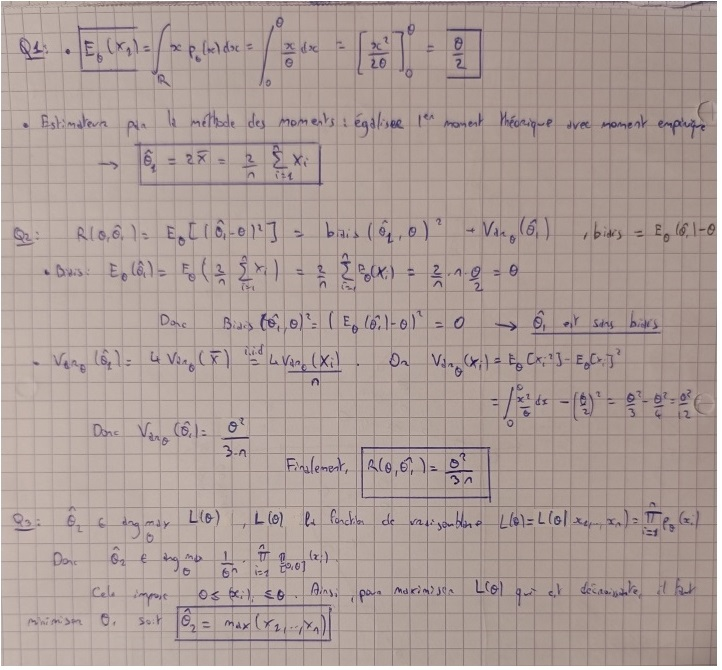

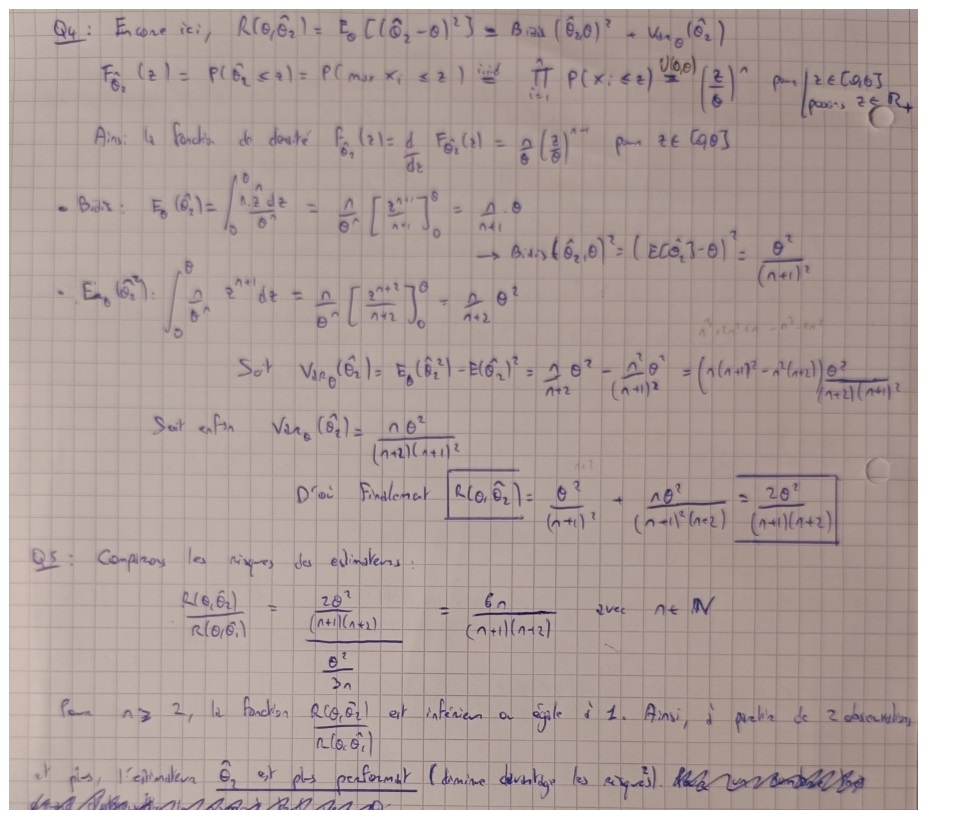

In [175]:
'''
img = mpimg.imread(img_path1)

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

img = mpimg.imread(img_path2)

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.show()
'''

"\nimg = mpimg.imread(img_path1)\n\nplt.figure(figsize=(12, 12))\nplt.imshow(img)\nplt.axis('off')\nplt.show()\n\nimg = mpimg.imread(img_path2)\n\nplt.figure(figsize=(12, 12))\nplt.imshow(img)\nplt.axis('off')\nplt.show()\n"

## Exercice 2 Box-Muller and Marsaglia-Bray algorithm

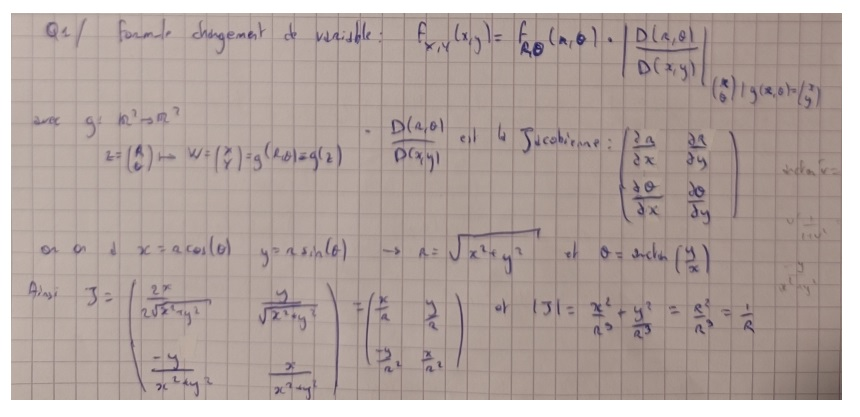

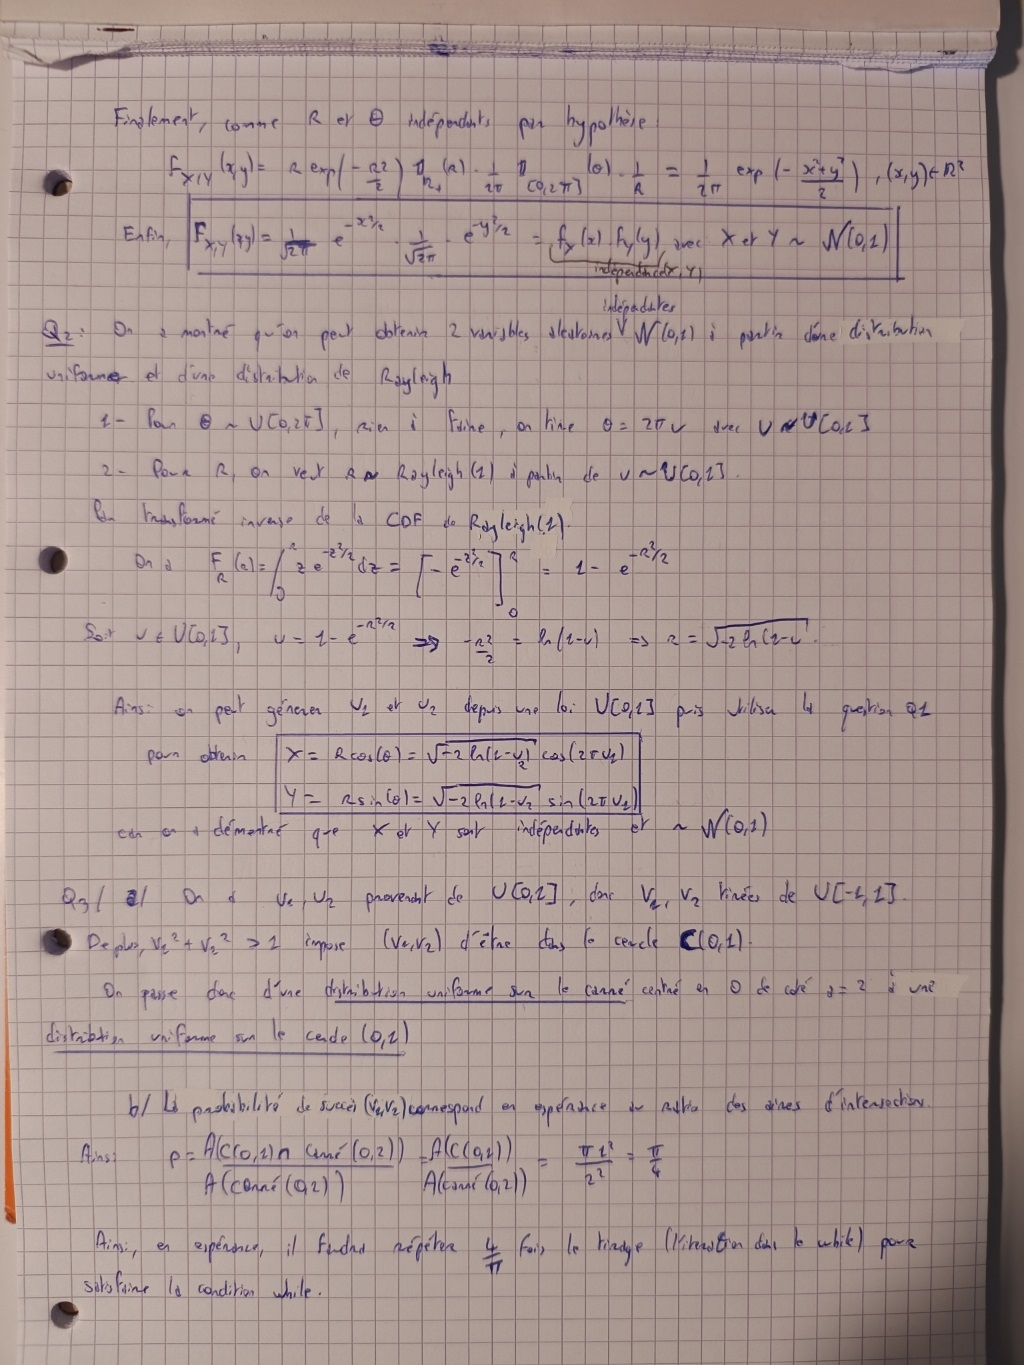

## Exercice 3: Learning a linear classifier


### Q1:

**TL;TR:**
I did a uniform sampling of n_samples points between 0 and 1, then i splitted the samples with specific w* and τ and plotted the whole.



In [176]:
# Fix the seed
np.random.seed(13)

# Used function
def custom_sign_function(h):
  '''
  compute y, being the sign of h=⟨w, x⟩ + τ,
  return: y as integer list and boolean list
  '''
  y_estim = np.sign(h) #(np.sign(h)+1)/2
  y_bool = y_estim == 1
  return y_estim.astype(int), y_bool

def compute_loss(y_true, h_estim):
  '''
  compute the empirical risk L_n(w,τ)
  '''
  sum_loss = (y_true - h_estim)**2
  n_sample = len(sum_loss)
  return sum_loss.sum()/n_sample

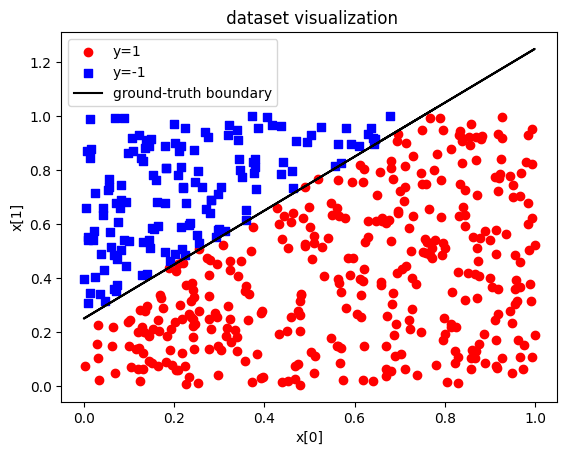

In [177]:
# Q1:

# Generate dataset
n_samples = 500 # n_sample
x_norm = np.random.rand(2, n_samples) # x[i,:] in [0,1] with uniform distribution
w_star = [0.5, -0.5] # for ~equidistribution visualization
tau = 0.15*(np.random.rand(1)*2-1)


# compute ground-truth of y
h = np.dot(w_star, x_norm) + tau
y_true, y_bool = custom_sign_function(h)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_GT = -(w_star[0] * x_norm[0,:])/w_star[1] - tau/w_star[1] # y_estim = x2 = -w1*x1/w2 - τ/w2


# plot
plt.figure()
plt.scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
plt.scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
plt.plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.title(" dataset visualization")
plt.legend()

plt.show()






### Q2 & Q3: Optimizing the loss by using Stochastic Gradient Descent (SGD)

**TL;TR:**

2/ I chose to compute the Empirical Risk as L_n(w,τ) and not just L_n(w), to optimize both parameters. Then, by taking the derivative w.r.t parameters, and applying  `w = w - eta*sto_grad_w & tau = tau - eta*sto_grad_tau` at each iteration, the algorithm should converge toward optimal parameters

3/ I chose to include 'batch' in the algorithm implementation, to enable the direct comparison of GD - SGD - mix(GD,SGD).
I found that GD takes more epochs to converge toward similar accuracy, and a mix of (GD,SGD) seems to provide the best comprimise between number of calculs and speed of convergence.

Interestingly, I also found that results are better when computing the SGD by using a loss with y_estim (error: y_truth - sign(h=⟨w, x⟩ + τ)) compared to the defined loss being relative to h_estim (error = y_truth - (h=⟨w, x⟩ + τ)). It's interesting because we could expect that loss with y_estim would be moslty non-differentiable (always 0 or 1), and so the gradient orientation would not be very informative for optimization, but seems that it's not the case for simple classification tasks as it is here.



#### **Pure SGD:**
Below, I tested : 1 sample per batch, 1 batch per epoch, and n_epochs number of epochs. =>
`n_calcul gradient = n_epoch`


In [178]:


def custom_SGD(yi_truth, hi_estim,x_batch, w, tau, eta, batch_size):
  '''
  Compute the gradient w.r.t parameters w and tau

  l_i = (yi​−h1)² = (yi-(⟨w,xi​⟩+tau))²
  '''

  # derivative of loss l_i w.r.t w
  sto_grad_w = -2*np.dot(x_batch,(yi_truth-hi_estim))/batch_size

  # derivative of loss l_i w.r.t tau
  sto_grad_tau = -2*sum(yi_truth-hi_estim)/batch_size

  w = w - eta*sto_grad_w
  tau = tau - eta*sto_grad_tau

  return w, tau


def training_SGD(x_norm,y_true, n_epochs,batch_size,max_iter_per_epoch):
  '''
  optimize the w and tau parameters with SGD


  return: w, tau, loss_evol
  '''
  #n_epochs = 500 # number of iteration for SGD
  eta = 0.01 # learning rate
  w = 0.5*(np.random.rand(2)*2-1)
  tau = float(0.3 *(np.random.rand()*2-1))
  loss_evol = []
  #batch_size = 1
  batch_size = min(batch_size, n_samples)
  #max_iter_per_epoch = 1

  for epoch in range(n_epochs):

    idx_samples = np.arange(n_samples)
    np.random.shuffle(idx_samples)
    loss_epoch = 0

    for n_iter, ibatch in enumerate(range(0,n_samples, batch_size)):
      '''
      # stochastic sample, batch_size will enable to compare SGD to GD
      '''
      if n_iter > max_iter_per_epoch: # limit the number of iteration per epoch for SGD
        break

      batch_idx = idx_samples[ibatch:ibatch+batch_size]

      x_batch = x_norm[:, batch_idx]
      y_batch_true = y_true[batch_idx]

      h_batch_estim = np.dot(w, x_batch) + tau
      y_batch_estim, y_batch_bool = custom_sign_function(h_batch_estim)

      loss = compute_loss(y_batch_true, h_batch_estim)
      loss_epoch += loss

      # Compute SGD and update parameters
      w, tau = custom_SGD(y_batch_true, h_batch_estim,x_batch, w, tau, eta, batch_size)
      #sys.exit()

    loss_evol.append(loss_epoch)

  return w, tau, loss_evol






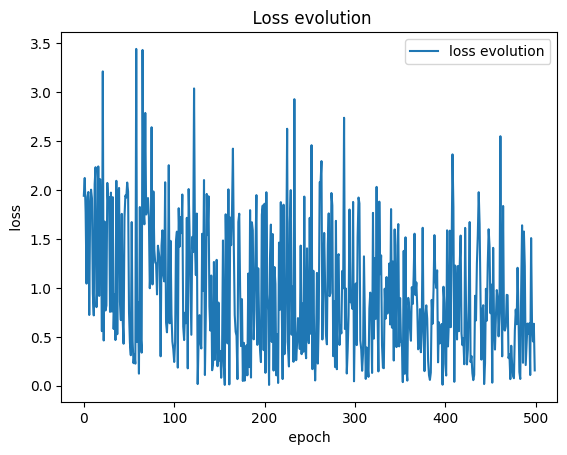

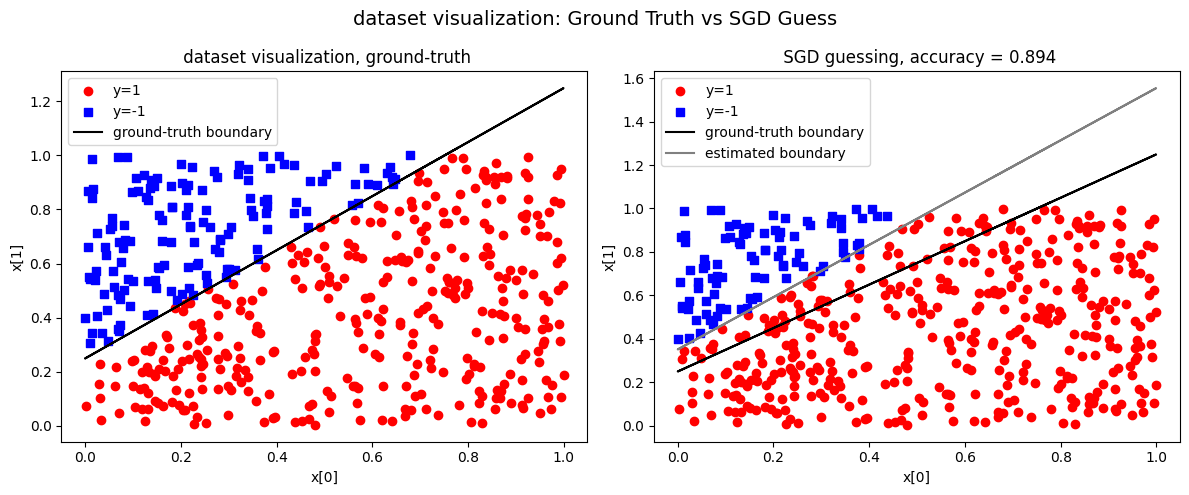

In [179]:
w, tau, loss_evol = training_SGD(x_norm,y_true, n_epochs=500,batch_size=1,max_iter_per_epoch=1)

# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()

# plot estimated separation

# compute ground-truth of y
h = np.dot(w, x_norm) + tau
y_estim, y_estim_bool = custom_sign_function(h)
loss = compute_loss(y_true, y_estim)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2



fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
axes[0].scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
axes[0].scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
axes[0].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[0].set_xlabel('x[0]')
axes[0].set_ylabel('x[1]')
axes[0].set_title(" dataset visualization, ground-truth")
axes[0].legend()

axes[1].scatter(x_norm[0, y_estim_bool], x_norm[1, y_estim_bool], color='red', marker='o', label="y=1")
axes[1].scatter(x_norm[0, ~y_estim_bool], x_norm[1, ~y_estim_bool], color='blue', marker='s', label="y=-1")
axes[1].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[1].plot(x_norm[0,:], h_boundary_estim,  color='grey', linestyle='-', label='estimated boundary')
axes[1].set_xlabel('x[0]')
axes[1].set_ylabel('x[1]')

# Compute accuracy
y_truth = y_bool.astype(int)
y_estim = y_estim_bool.astype(int)
y_combined = y_truth + y_estim
acc_bool = y_combined == 1
acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)


axes[1].set_title(f" SGD guessing, accuracy = {acc}")
axes[1].legend()

plt.suptitle("dataset visualization: Ground Truth vs SGD Guess", fontsize=14)
plt.tight_layout()
plt.show()

#### **GD:**
Below, I tested : n samples per batch, 1 batch per epoch, and n_epochs number of epochs. =>
`n_calcul gradient = n_epoch*n_samples`




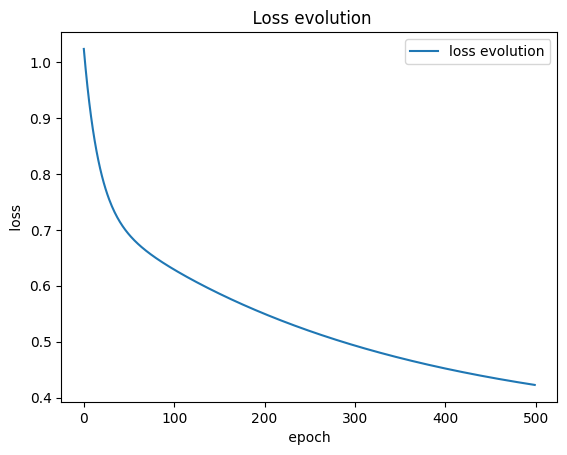

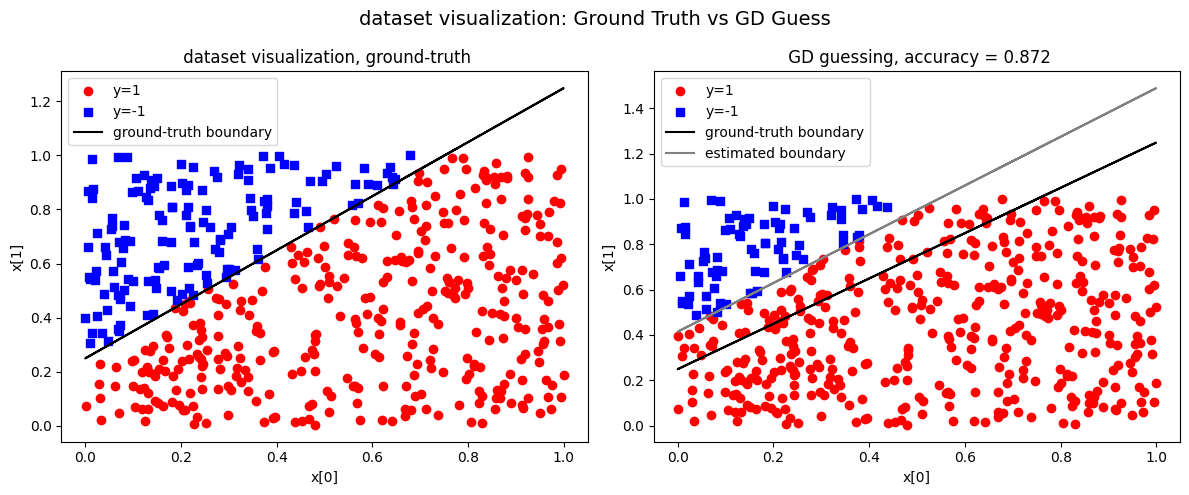

In [180]:
w, tau, loss_evol = training_SGD(x_norm,y_true, n_epochs=500,batch_size=n_samples,max_iter_per_epoch=1)

# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()

# plot estimated separation

# compute ground-truth of y
h = np.dot(w, x_norm) + tau
y_estim, y_estim_bool = custom_sign_function(h)
loss = compute_loss(y_true, y_estim)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2



fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
axes[0].scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
axes[0].scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
axes[0].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[0].set_xlabel('x[0]')
axes[0].set_ylabel('x[1]')
axes[0].set_title(" dataset visualization, ground-truth")
axes[0].legend()

axes[1].scatter(x_norm[0, y_estim_bool], x_norm[1, y_estim_bool], color='red', marker='o', label="y=1")
axes[1].scatter(x_norm[0, ~y_estim_bool], x_norm[1, ~y_estim_bool], color='blue', marker='s', label="y=-1")
axes[1].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[1].plot(x_norm[0,:], h_boundary_estim,  color='grey', linestyle='-', label='estimated boundary')
axes[1].set_xlabel('x[0]')
axes[1].set_ylabel('x[1]')

# Compute accuracy
y_truth = y_bool.astype(int)
y_estim = y_estim_bool.astype(int)
y_combined = y_truth + y_estim
acc_bool = y_combined == 1
acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)


axes[1].set_title(f" GD guessing, accuracy = {acc}")
axes[1].legend()

plt.suptitle("dataset visualization: Ground Truth vs GD Guess", fontsize=14)
plt.tight_layout()
plt.show()

#### **mix GD & SGD:**
Below, I tested : batch_size samples per batch per epoch, max_iter_per_epoch batches, and n_epochs number of epochs. =>
`n_calcul gradient = n_epoch*batch_size*max_iter_per_epoch`







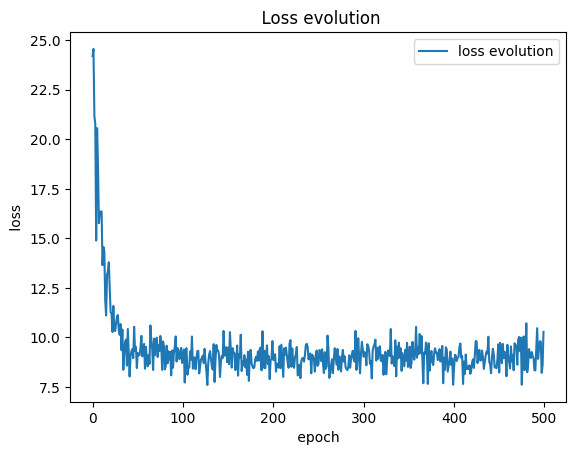

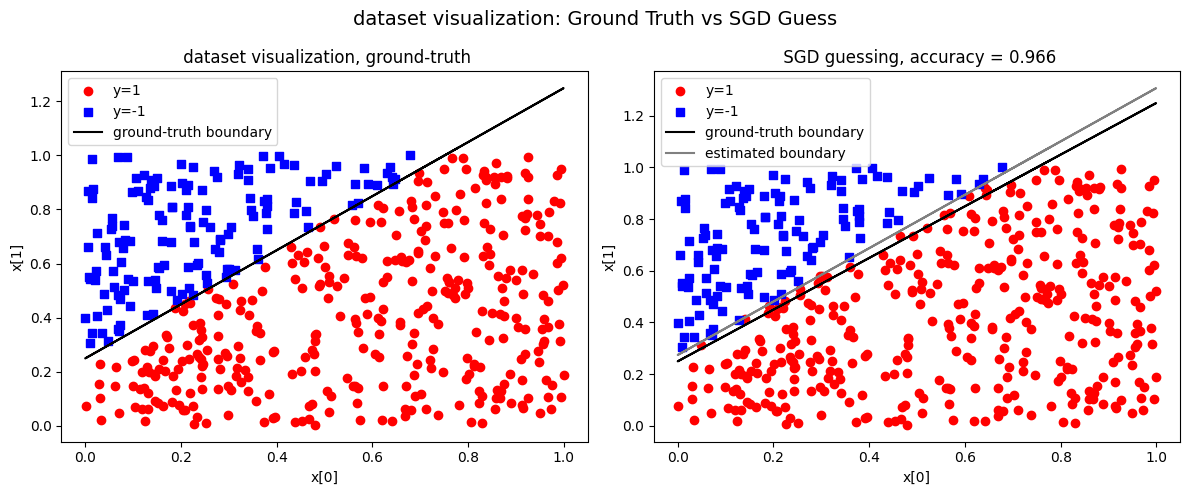

In [181]:
w, tau, loss_evol = training_SGD(x_norm,y_true, n_epochs=500,batch_size=5,max_iter_per_epoch=25)

# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()

# plot estimated separation

# compute ground-truth of y
h = np.dot(w, x_norm) + tau
y_estim, y_estim_bool = custom_sign_function(h)
loss = compute_loss(y_true, y_estim)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2



fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
axes[0].scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
axes[0].scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
axes[0].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[0].set_xlabel('x[0]')
axes[0].set_ylabel('x[1]')
axes[0].set_title(" dataset visualization, ground-truth")
axes[0].legend()

axes[1].scatter(x_norm[0, y_estim_bool], x_norm[1, y_estim_bool], color='red', marker='o', label="y=1")
axes[1].scatter(x_norm[0, ~y_estim_bool], x_norm[1, ~y_estim_bool], color='blue', marker='s', label="y=-1")
axes[1].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[1].plot(x_norm[0,:], h_boundary_estim,  color='grey', linestyle='-', label='estimated boundary')
axes[1].set_xlabel('x[0]')
axes[1].set_ylabel('x[1]')

# Compute accuracy
y_truth = y_bool.astype(int)
y_estim = y_estim_bool.astype(int)
y_combined = y_truth + y_estim
acc_bool = y_combined == 1
acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)


axes[1].set_title(f" SGD guessing, accuracy = {acc}")
axes[1].legend()

plt.suptitle("dataset visualization: Ground Truth vs SGD Guess", fontsize=14)
plt.tight_layout()
plt.show()

#### I tested below the use of y_estim instead of h_estim in the loss

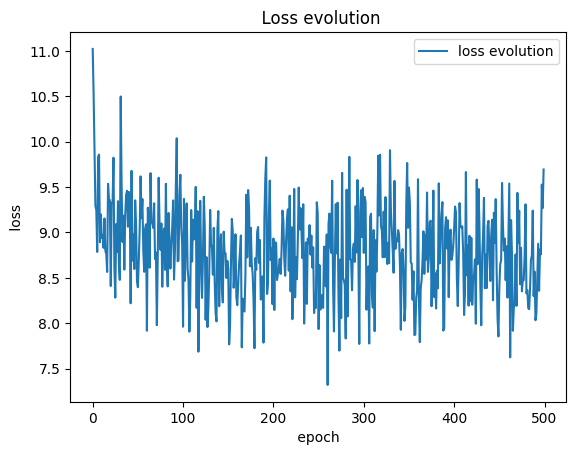

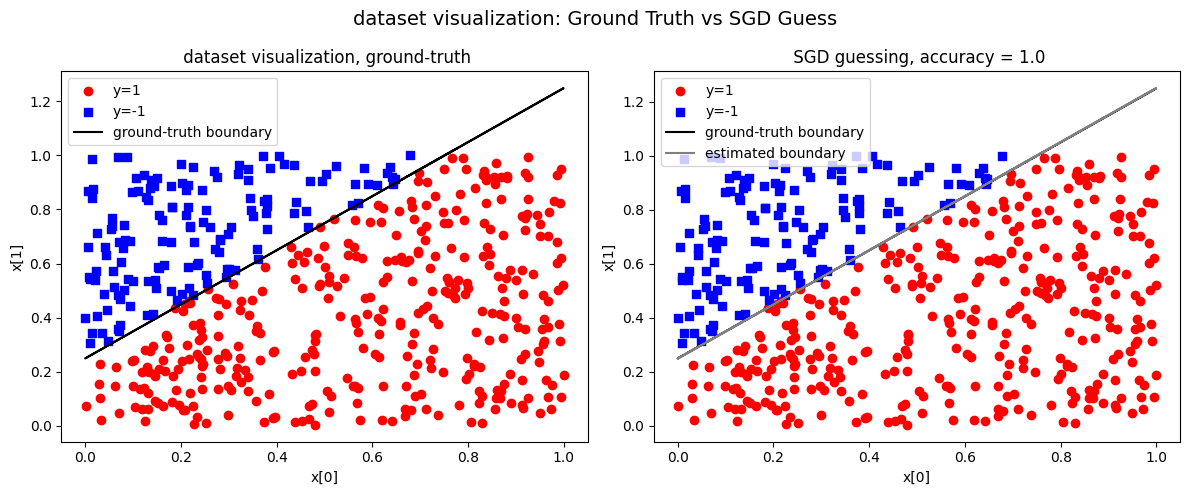

In [182]:




def training_SGD_test(x_norm,y_true, n_epochs,batch_size,max_iter_per_epoch):
  '''
  optimize the w and tau parameters with SGD


  return: w, tau, loss_evol
  '''
  #n_epochs = 500 # number of iteration for SGD
  eta = 0.01 # learning rate
  w = 0.5*(np.random.rand(2)*2-1)
  tau = float(0.3 *(np.random.rand()*2-1))
  loss_evol = []
  #batch_size = 1
  batch_size = min(batch_size, n_samples)
  #max_iter_per_epoch = 1

  for epoch in range(n_epochs):

    idx_samples = np.arange(n_samples)
    np.random.shuffle(idx_samples)
    loss_epoch = 0

    for n_iter, ibatch in enumerate(range(0,n_samples, batch_size)):
      '''
      # stochastic sample, batch_size will enable to compare SGD to GD
      '''
      if n_iter > max_iter_per_epoch: # limit the number of iteration per epoch for SGD
        break

      batch_idx = idx_samples[ibatch:ibatch+batch_size]

      x_batch = x_norm[:, batch_idx]
      y_batch_true = y_true[batch_idx]

      h_batch_estim = np.dot(w, x_batch) + tau
      y_batch_estim, y_batch_bool = custom_sign_function(h_batch_estim)

      loss = compute_loss(y_batch_true, h_batch_estim)
      loss_epoch += loss

      # Compute SGD and update parameters
      w, tau = custom_SGD(y_batch_true, y_batch_estim,x_batch, w, tau, eta, batch_size)
      #sys.exit()

    loss_evol.append(loss_epoch)

  return w, tau, loss_evol



w, tau, loss_evol = training_SGD_test(x_norm,y_true, n_epochs=500,batch_size=1,max_iter_per_epoch=10)

# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()

# plot estimated separation

# compute ground-truth of y
h = np.dot(w, x_norm) + tau
y_estim, y_estim_bool = custom_sign_function(h)
loss = compute_loss(y_true, y_estim)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2



fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
axes[0].scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
axes[0].scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
axes[0].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[0].set_xlabel('x[0]')
axes[0].set_ylabel('x[1]')
axes[0].set_title(" dataset visualization, ground-truth")
axes[0].legend()

axes[1].scatter(x_norm[0, y_estim_bool], x_norm[1, y_estim_bool], color='red', marker='o', label="y=1")
axes[1].scatter(x_norm[0, ~y_estim_bool], x_norm[1, ~y_estim_bool], color='blue', marker='s', label="y=-1")
axes[1].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[1].plot(x_norm[0,:], h_boundary_estim,  color='grey', linestyle='-', label='estimated boundary')
axes[1].set_xlabel('x[0]')
axes[1].set_ylabel('x[1]')

# Compute accuracy
y_truth = y_bool.astype(int)
y_estim = y_estim_bool.astype(int)
y_combined = y_truth + y_estim
acc_bool = y_combined == 1
acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)


axes[1].set_title(f" SGD guessing, accuracy = {acc}")
axes[1].legend()

plt.suptitle("dataset visualization: Ground Truth vs SGD Guess", fontsize=14)
plt.tight_layout()
plt.show()

#### Q4: additive Gaussian noise in the observation

**TL;TR:**

I used the same function as for Q2-Q3, and modified x_norm to become `x_nom=x_norm + x_noise`.
With sigma noise = 0.25 (very significant noise because x belongs to [0,1]), We see as expected that the loss curve is significantly noisier, and lose accuracy is lost_accuracy = 0.994-0.874, thus -12% accuracy, but interestingly, SGD still manage to converge.



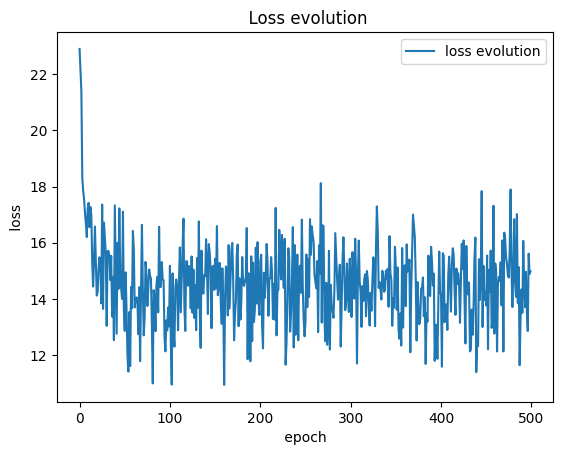

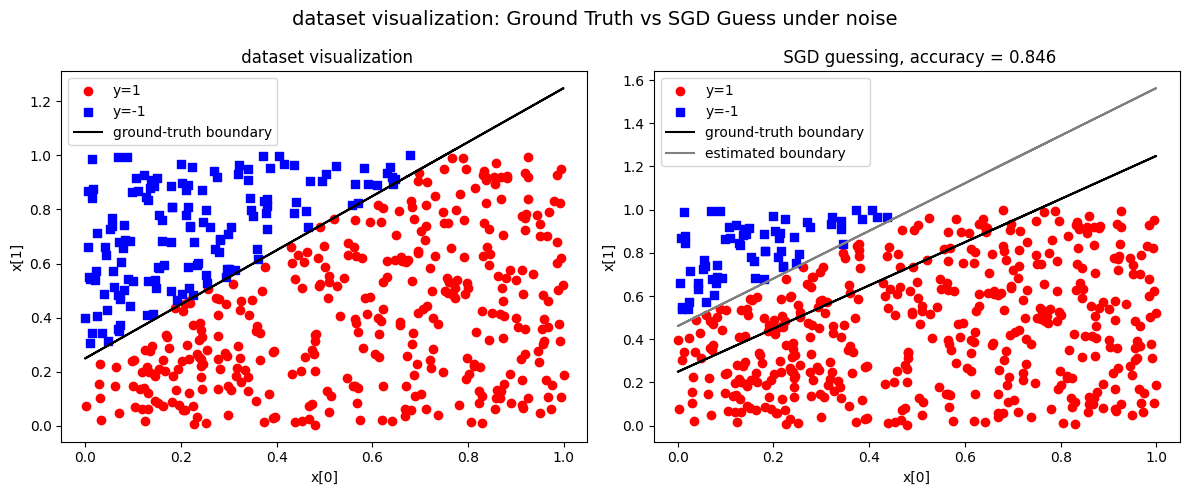

In [183]:
# Q4:
def add_gaussian_noise(x, sigma):
    return x + sigma * np.random.randn(*x.shape)

x_noise = add_gaussian_noise(x_norm, 0.25)

w, tau, loss_evol = training_SGD(x_noise,y_true, n_epochs=500,batch_size=5,max_iter_per_epoch=25)


# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()

# plot estimated separation

# compute ground-truth of y
h = np.dot(w, x_norm) + tau
y_estim, y_estim_bool = custom_sign_function(h)
loss = compute_loss(y_true, y_estim)

# compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2



fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
axes[0].scatter(x_norm[0, y_bool], x_norm[1, y_bool], color='red', marker='o', label="y=1")
axes[0].scatter(x_norm[0, ~y_bool], x_norm[1, ~y_bool], color='blue', marker='s', label="y=-1")
axes[0].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[0].set_xlabel('x[0]')
axes[0].set_ylabel('x[1]')
axes[0].set_title(" dataset visualization")
axes[0].legend()

axes[1].scatter(x_norm[0, y_estim_bool], x_norm[1, y_estim_bool], color='red', marker='o', label="y=1")
axes[1].scatter(x_norm[0, ~y_estim_bool], x_norm[1, ~y_estim_bool], color='blue', marker='s', label="y=-1")
axes[1].plot(x_norm[0,:], h_boundary_GT, 'k-', label='ground-truth boundary')
axes[1].plot(x_norm[0,:], h_boundary_estim,  color='grey', linestyle='-', label='estimated boundary')
axes[1].set_xlabel('x[0]')
axes[1].set_ylabel('x[1]')

# Compute accuracy
y_truth = y_bool.astype(int)
y_estim = y_estim_bool.astype(int)
y_combined = y_truth + y_estim
acc_bool = y_combined == 1
acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)


axes[1].set_title(f" SGD guessing, accuracy = {acc}")
axes[1].legend()

plt.suptitle("dataset visualization: Ground Truth vs SGD Guess under noise", fontsize=14)
plt.tight_layout()
plt.show()

### Q5: Heart Disease (Diagnostic) Data Set

Source of the database: https://archive.ics.uci.edu/dataset/45/heart+disease

Important note:
*The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  *

**TL;TR:**

I used the exact same SGD otpimizer, by only replacing w which was size (2,), by w of size (n_features,) with n_features = 11 (I removed the features with 'missing values').
I obtained 81.25% Accuracy, which is pretty good regarding to the fact that the website reports accuracy_max = 81.579 achieved by Xgboost and Logistic regression.

In [184]:
# Codes given by the dataset website:
# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X_original = heart_disease.data.features
y_original = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)

n_class, occ = np.unique(y_original, return_counts=True)
print(n_class, occ)
print(X_original.shape)
n_samples, n_features = X_original.shape

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [185]:

# Extract readable data
X = X_original.to_numpy()
X = X[:,:11] # remove the features that have 'missing values'
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

# Standardize each column: z = (x - mean) / std
X_std = (X - mu) / sigma
# Normalize each column
X_min = X_std.min(axis=0)
X_max = X_std.max(axis=0)
X_norm = (X_std - X_min) / (X_max - X_min)
n_samples, n_features = X_norm.shape
x_norm = X_norm.T

y_bin = (y_original['num'] > 0).astype(int) # Binarize the class, {0} --> 0 & {1,2,3,4} --> 1
y = y_bin.to_numpy().reshape(-1) # we want numpy format
y_true = y*2-1 # y belongs to {-1,1}
y_bool = y_true > 0


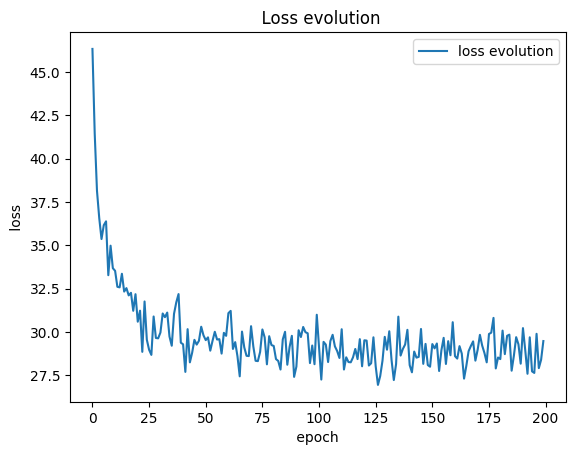

 Accuracy =  0.8125412541254124


In [204]:
def custom_SGD(yi_truth, hi_estim,x_batch, w, tau, eta, batch_size):
  '''
  Compute the gradient w.r.t parameters w and tau

  l_i ​= (yi​−hi​)² = (yi-(⟨w,xi​⟩+tau))²
  '''

  # derivative of loss l_i w.r.t w
  sto_grad_w = -2*np.dot(x_batch,(yi_truth-hi_estim))/batch_size

  # derivative of loss l_i w.r.t tau
  sto_grad_tau = -2*sum(yi_truth-hi_estim)/batch_size

  w = w - eta*sto_grad_w
  tau = tau - eta*sto_grad_tau

  return w, tau


def training_SGD(x_norm,y_true, n_epochs,batch_size,max_iter_per_epoch):
  '''
  optimize the w and tau parameters with SGD


  return: w, tau, loss_evol
  '''
  eta = 0.01 # learning rate
  w = 0.5*(np.random.rand(n_features)*2-1)
  tau = float(0.3 *(np.random.rand()*2-1))
  loss_evol = []
  batch_size = min(batch_size, n_samples)

  for epoch in range(n_epochs):

    idx_samples = np.arange(n_samples)
    np.random.shuffle(idx_samples)
    loss_epoch = 0

    for n_iter, ibatch in enumerate(range(0,n_samples, batch_size)):
      '''
      # stochastic sample, batch_size will enable to compare SGD to GD
      '''
      if n_iter > max_iter_per_epoch: # limit the number of iteration per epoch for SGD
        break

      batch_idx = idx_samples[ibatch:ibatch+batch_size]

      x_batch = x_norm[:, batch_idx]
      y_batch_true = y_true[batch_idx]

      h_batch_estim = np.dot(w, x_batch) + tau
      y_batch_estim, y_batch_bool = custom_sign_function(h_batch_estim)

      loss = compute_loss(y_batch_true, h_batch_estim)
      loss_epoch += loss

      # Compute SGD and update parameters
      w, tau = custom_SGD(y_batch_true, h_batch_estim,x_batch, w, tau, eta, batch_size)
      #sys.exit()

    loss_evol.append(loss_epoch)

  return w, tau, loss_evol


acc_mean = []
for _ in range(10):
  w, tau, loss_evol = training_SGD(x_norm,y_true, n_epochs=200,batch_size=5,max_iter_per_epoch=50)

  # compute ground-truth of y
  h = np.dot(w, x_norm) + tau
  y_estim, y_estim_bool = custom_sign_function(h)
  loss = compute_loss(y_true, y_estim)

  # compute the hyperplane decision boundary s.t h = ⟨w, x⟩ + τ = 0
  h_boundary_estim = -(w[0] * x_norm[0,:])/w[1] - tau/w[1] # y_estim = x2 = -w1*x1/w2 - τ/w2

  # Compute accuracy
  y_truth = y_bool.astype(int)
  y_estim = y_estim_bool.astype(int)
  y_combined = y_truth + y_estim
  acc_bool = y_combined == 1
  acc = (len(acc_bool) - sum(acc_bool))/len(acc_bool)

  acc_mean.append(acc)

# plot loss evolution per epoch
plt.figure()
plt.plot(np.arange(len(loss_evol)),loss_evol,label="loss evolution")
plt.xlabel(' epoch ')
plt.ylabel(' loss ')
plt.title(f"  Loss evolution ")
plt.legend()
plt.show()



print(" Accuracy = ", np.mean(acc_mean))